=== DATASET PROFILE ===
Shape: (891, 15)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

Summary Statistics:
          

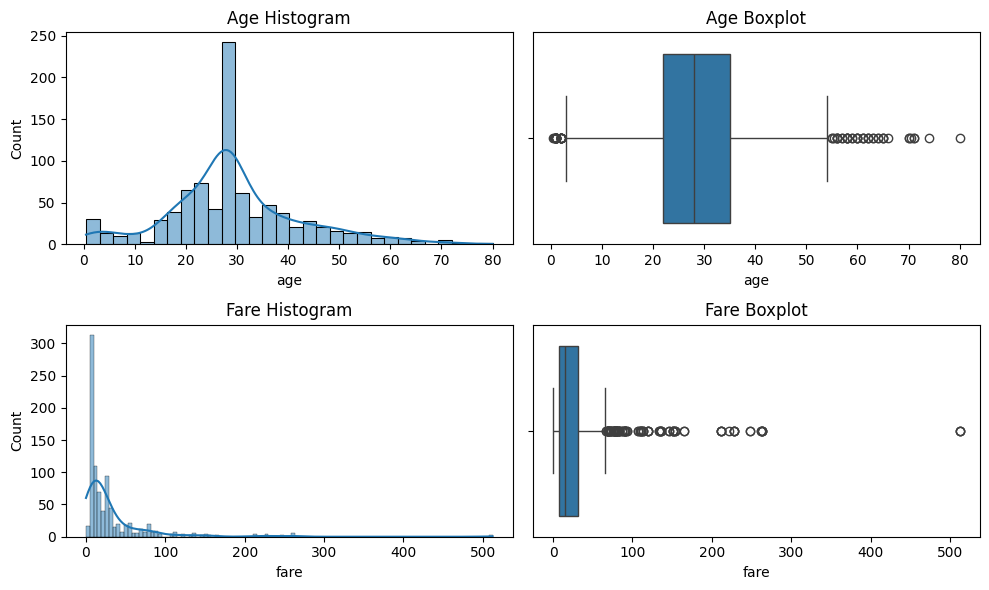

Age Outliers: 65
Fare Outliers: 114
Fare Mean: 32.10 | Median: 14.45 | Mode: 8.05

=== SURVIVAL RATES ===
Sex (Female): 0.7403846153846154
Sex (Male): 0.18890814558058924
Pclass 1: 0.6261682242990654
Pclass 2: 0.47282608695652173
Pclass 3: 0.24236252545824846
Female & Pclass 1: 0.967391304347826


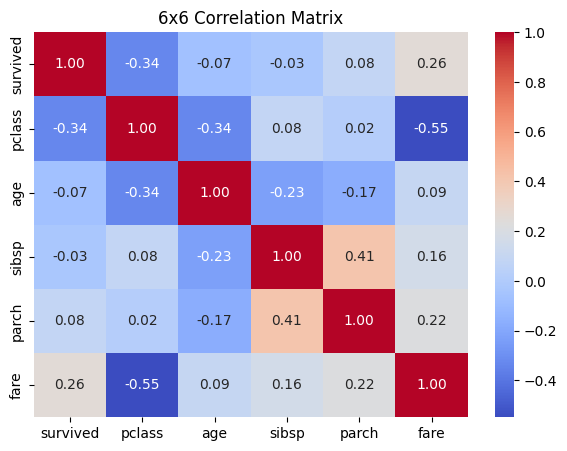

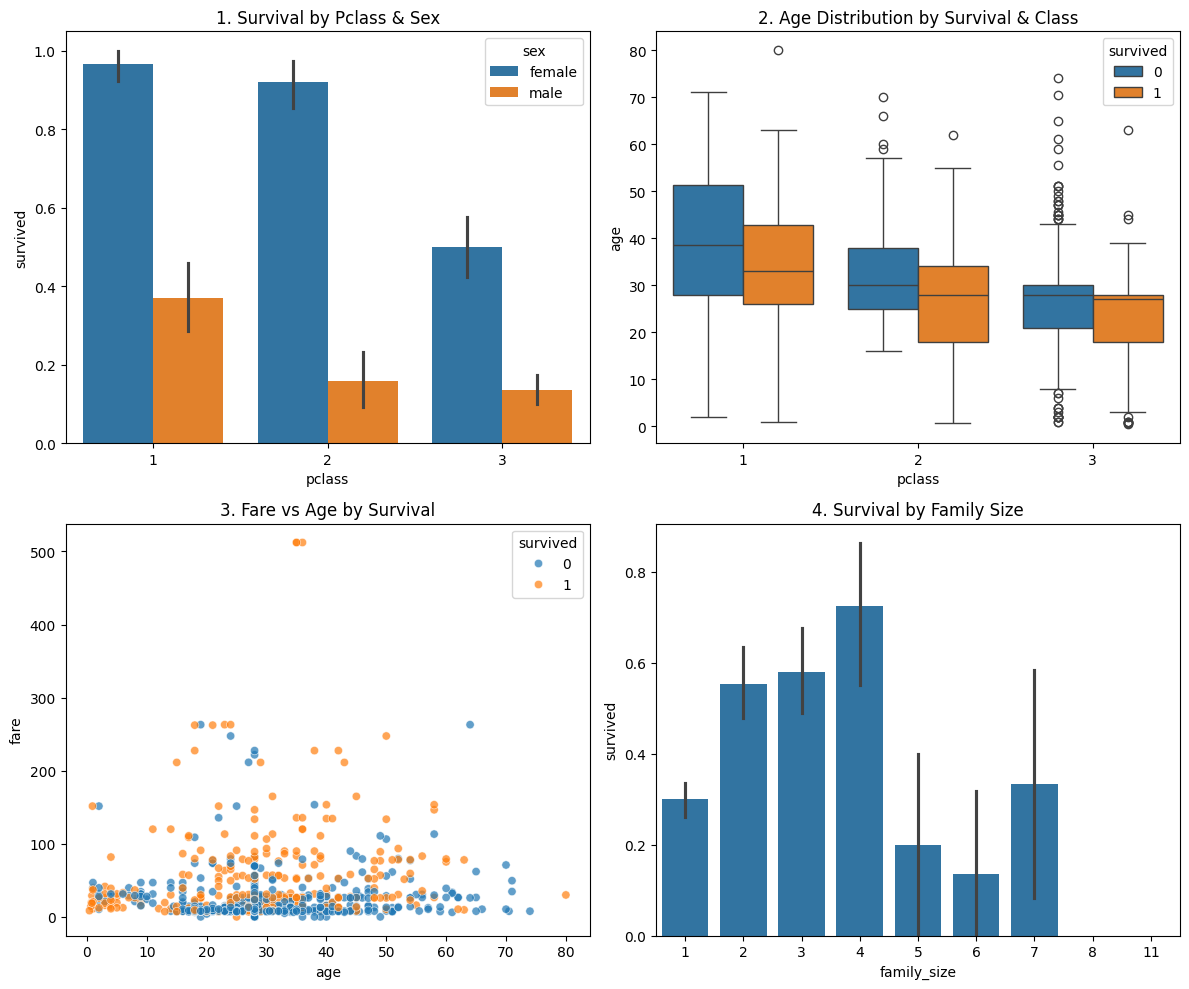

Standardized Means: [2.71748628e-16 1.39870617e-16] | Stds: [1. 1.]


In [1]:
!pip install -q imbalanced-learn scikit-learn seaborn pandas matplotlib joblib

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load raw dataset ONCE and save offline fallback
try:
    df = sns.load_dataset('titanic')
except Exception:
    df = pd.read_csv("titanic.csv")

df.to_csv("titanic.csv", index=False)

print("=== DATASET PROFILE ===")
print(f"Shape: {df.shape}\n")
print("Info:")
df.info()
print("\nSummary Statistics:")
print(df.describe(include='all'))

# Missing value calculation
missing_pct = (df.isnull().sum() / len(df)) * 100
print("\nMissing Percentages:\n", missing_pct[missing_pct > 0].sort_values(ascending=False))

# 2. Missing-Value Handling per column rules
df_clean = df.copy()
if 'deck' in df_clean.columns:
    df_clean['deck'] = df_clean['deck'].cat.add_categories('Unknown').fillna('Unknown')
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())
df_clean = df_clean.dropna(subset=['embarked', 'embark_town'])

# 3. Univariate Analysis (Age & Fare)
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
sns.histplot(df_clean['age'], kde=True, ax=axes[0, 0]).set(title='Age Histogram')
sns.boxplot(x=df_clean['age'], ax=axes[0, 1]).set(title='Age Boxplot')
sns.histplot(df_clean['fare'], kde=True, ax=axes[1, 0]).set(title='Fare Histogram')
sns.boxplot(x=df_clean['fare'], ax=axes[1, 1]).set(title='Fare Boxplot')
plt.tight_layout()
plt.show()

# Outliers IQR
def iqr_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return len(s[(s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)])

print(f"Age Outliers: {iqr_outliers(df_clean['age'])}")
print(f"Fare Outliers: {iqr_outliers(df_clean['fare'])}")
print(f"Fare Mean: {df_clean['fare'].mean():.2f} | Median: {df_clean['fare'].median():.2f} | Mode: {df_clean['fare'].mode()[0]:.2f}")

# 4. Bivariate Analysis & Heatmap
print("\n=== SURVIVAL RATES ===")
print("Sex (Female):", df_clean[df_clean['sex'] == 'female']['survived'].mean())
print("Sex (Male):", df_clean[df_clean['sex'] == 'male']['survived'].mean())
print("Pclass 1:", df_clean[df_clean['pclass'] == 1]['survived'].mean())
print("Pclass 2:", df_clean[df_clean['pclass'] == 2]['survived'].mean())
print("Pclass 3:", df_clean[df_clean['pclass'] == 3]['survived'].mean())
print("Female & Pclass 1:", df_clean[(df_clean['sex'] == 'female') & (df_clean['pclass'] == 1)]['survived'].mean())

# Heatmap (exactly 6 numeric columns, excluding adult_male and alone)
corr_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
plt.figure(figsize=(7, 5))
sns.heatmap(df_clean[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("6x6 Correlation Matrix")
plt.show()

# 5. Multivariate 4 Charts Data Story
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.barplot(data=df_clean, x='pclass', y='survived', hue='sex', ax=axes[0, 0]).set(title="1. Survival by Pclass & Sex")
sns.boxplot(data=df_clean, x='pclass', y='age', hue='survived', ax=axes[0, 1]).set(title="2. Age Distribution by Survival & Class")
sns.scatterplot(data=df_clean, x='age', y='fare', hue='survived', alpha=0.7, ax=axes[1, 0]).set(title="3. Fare vs Age by Survival")
df_clean['family_size'] = df_clean['sibsp'] + df_clean['parch'] + 1
sns.barplot(data=df_clean, x='family_size', y='survived', ax=axes[1, 1]).set(title="4. Survival by Family Size")
plt.tight_layout()
plt.show()

# 6. Standardization check
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
std_check = scaler.fit_transform(df_clean[['age', 'fare']])
print(f"Standardized Means: {std_check.mean(axis=0)} | Stds: {std_check.std(axis=0)}")

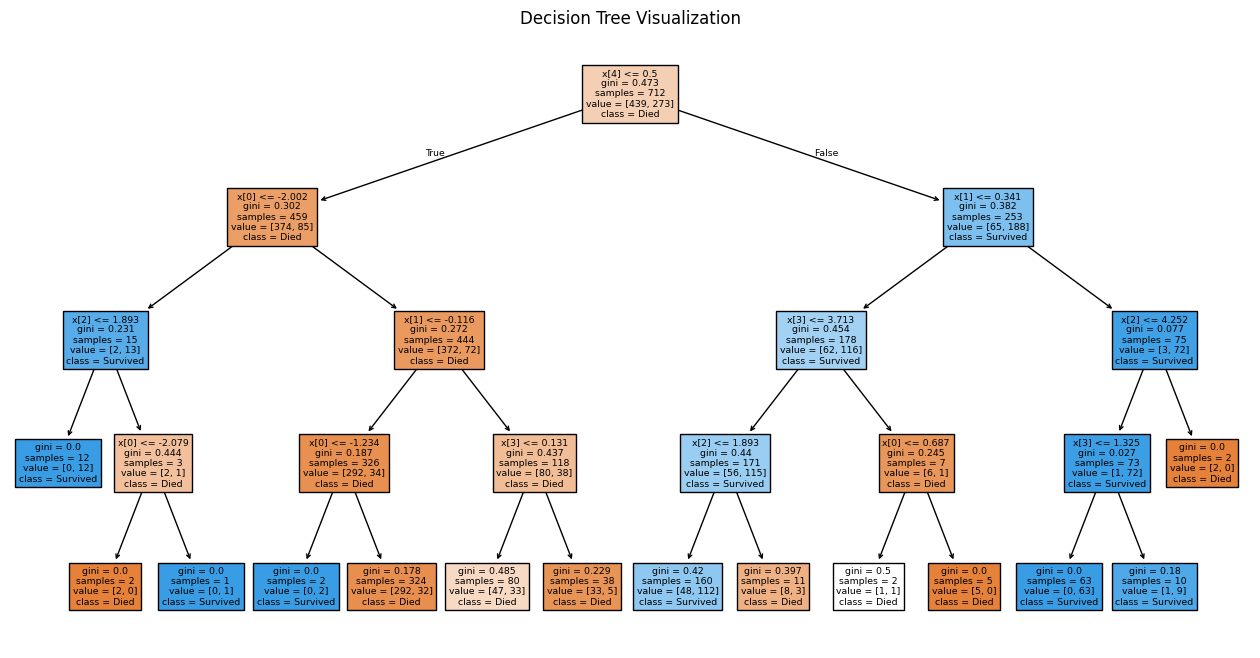

=== CLASSIFIER METRICS ===
                     Accuracy  Precision    Recall        F1       AUC
Logistic Regression  0.798883   0.779661  0.666667  0.718750  0.819499
Decision Tree        0.810056   0.796610  0.681159  0.734375  0.839394
Random Forest        0.793296   0.758065  0.681159  0.717557  0.822925

=== IMBALANCE COMPARISON ===
          Precision    Recall        F1
Baseline   0.758065  0.681159  0.717557
Balanced   0.758065  0.681159  0.717557
SMOTE      0.700000  0.710145  0.705036

Best Params: {'rf__max_depth': 4, 'rf__max_features': 'sqrt', 'rf__n_estimators': 200}
OOB Score: 0.8104

=== REGRESSION METRICS ===
MAE: 17.22 | RMSE: 37.37 | R2: 0.4337 | Adj R2: 0.4253


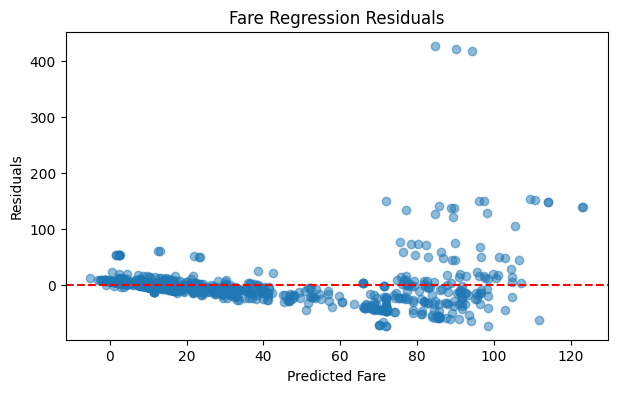


Reloaded Pipeline Test Prediction: 1


In [2]:
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Read strictly from committed offline CSV
df_model = pd.read_csv("titanic.csv")

# 1. Stratified Split
X = df_model.drop(columns=['survived', 'alive'], errors='ignore')
y = df_model['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2. Preprocessing ColumnTransformer
num_cols = ['age', 'fare', 'sibsp', 'parch']
cat_cols = ['sex', 'embarked']

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')), ('encoder', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
])

# 3. Model Training & Decision Tree Visual
dt_pipe = Pipeline([('prep', preprocessor), ('dt', DecisionTreeClassifier(max_depth=4, random_state=42))])
dt_pipe.fit(X_train, y_train)

plt.figure(figsize=(16, 8))
plot_tree(dt_pipe.named_steps['dt'], filled=True, class_names=['Died', 'Survived'])
plt.title("Decision Tree Visualization")
plt.show()

# 4. Evaluate Three Classifiers
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, clf in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_prob)
    }

print("=== CLASSIFIER METRICS ===")
print(pd.DataFrame(results).T)

# 5. Imbalance Comparison
imb_pipes = {
    'Baseline': Pipeline([('prep', preprocessor), ('rf', RandomForestClassifier(random_state=42))]),
    'Balanced': Pipeline([('prep', preprocessor), ('rf', RandomForestClassifier(class_weight='balanced', random_state=42))]),
    'SMOTE': ImbPipeline([('prep', preprocessor), ('smote', SMOTE(random_state=42)), ('rf', RandomForestClassifier(random_state=42))])
}

imb_res = {}
for k, pipe in imb_pipes.items():
    pipe.fit(X_train, y_train)
    y_p = pipe.predict(X_test)
    imb_res[k] = {'Precision': precision_score(y_test, y_p), 'Recall': recall_score(y_test, y_p), 'F1': f1_score(y_test, y_p)}

print("\n=== IMBALANCE COMPARISON ===")
print(pd.DataFrame(imb_res).T)

# 6. Hyperparameter Tuning with oob_score=True
rf_oob = RandomForestClassifier(oob_score=True, random_state=42)
tune_pipe = Pipeline([('prep', preprocessor), ('rf', rf_oob)])

param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [4, 6, 8],
    'rf__max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(tune_pipe, param_grid, cv=5, scoring='f1')
grid.fit(X_train, y_train)

print(f"\nBest Params: {grid.best_params_}")
print(f"OOB Score: {grid.best_estimator_.named_steps['rf'].oob_score_:.4f}")

# 7. Regression Side-Task (Predicting Fare)
df_reg = df_model.dropna(subset=['fare']).copy()
X_reg = df_reg.drop(columns=['fare', 'alive'], errors='ignore')
y_reg = df_reg['fare']

reg_prep = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), ['age', 'sibsp', 'parch']),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')), ('encoder', OneHotEncoder(handle_unknown='ignore'))]), ['sex', 'embarked', 'pclass'])
])

reg_pipe = Pipeline([('prep', reg_prep), ('reg', LinearRegression())])
reg_pipe.fit(X_reg, y_reg)
y_reg_pred = reg_pipe.predict(X_reg)

mae = mean_absolute_error(y_reg, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg, y_reg_pred))
r2 = r2_score(y_reg, y_reg_pred)
adj_r2 = 1 - (1 - r2) * (len(y_reg) - 1) / (len(y_reg) - X_reg.shape[1] - 1)

print(f"\n=== REGRESSION METRICS ===")
print(f"MAE: {mae:.2f} | RMSE: {rmse:.2f} | R2: {r2:.4f} | Adj R2: {adj_r2:.4f}")

plt.figure(figsize=(7, 4))
plt.scatter(y_reg_pred, y_reg - y_reg_pred, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Fare Regression Residuals")
plt.show()

# 8. Export Complete Pipeline Artifact & Verify
joblib.dump(grid.best_estimator_, 'full_pipeline.joblib')

loaded_pipeline = joblib.load('full_pipeline.joblib')
sample_raw = pd.DataFrame([{
    'pclass': 1, 'sex': 'female', 'age': 28.0, 'sibsp': 0, 'parch': 0,
    'fare': 100.0, 'embarked': 'S', 'class': 'First', 'who': 'woman',
    'adult_male': False, 'deck': 'C', 'embark_town': 'Southampton', 'alone': True
}])
print("\nReloaded Pipeline Test Prediction:", loaded_pipeline.predict(sample_raw)[0])

In [4]:
from google.colab import files

files.download('titanic.csv')
files.download('full_pipeline.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>